# Analyse results from Pypsa-Earth

Sources: 
- Plot capacity - map view: https://github.com/pypsa-meets-earth/documentation/blob/main/notebooks/viz/regional_transm_system_viz.ipynb
- Analyse energy potential: https://github.com/pypsa-meets-earth/documentation/blob/main/notebooks/build_renewable_profiles.ipynb
- Analyse energy generation: https://pypsa.readthedocs.io/en/latest/examples/statistics.html

Some files are needed:
* PyPSA network file (e.g. "elec.nc" contains a lot of details and looks perfect)
* a country shape file (may be found in "resources/shapes/country_shapes.geojson")
* a renewable profile file (may be found in "resources/renewable_profiles/....nc)

## Own setting

In [46]:
import os
import sys
import yaml

PARENT = os.path.realpath("../../pypsa-earth") + "/"
config = yaml.safe_load(open(PARENT + "config-2030-GADM-NetZero.yaml"))

# Read config.yaml settings:
name = config["run"]["name"]
simpl = config["scenario"]["simpl"]
# clusters = "10"
clusters = config["scenario"]["clusters"]
ll = config["scenario"]["ll"]
opts = config["scenario"]["opts"]

# Ensure elements are strings and properly joined
simpl_str = "_".join(map(str, simpl))
clusters_str = "_".join(map(str, clusters))
#clusters_str = clusters
ll_str = "_".join(map(str, ll))
opts_str = "_".join(map(str, opts))
export = "1"
geothermal_potential = "3"

## Import packages

In [47]:
import yaml
import pypsa
import warnings
import matplotlib.pyplot as plt
import geopandas as gpd
import numpy as np
import pandas as pd
from pathlib import Path
import seaborn as sns
from datetime import datetime
from cartopy import crs as ccrs
from pypsa.plot import add_legend_circles, add_legend_lines, add_legend_patches
import os
import xarray as xr
import cartopy

## Path settings

In [48]:
# nc_file_name = f"elec_s{simpl_str}_{clusters_str}_ec_l{ll_str}_{opts_str}-{export}-{geothermal_potential}.nc"
nc_file_name = f"elec_s{simpl_str}_{clusters_str}_ec_l{ll_str}_{opts_str}.nc"
scenario_name = name 
scenario_subpath = scenario_name + "/" if scenario_name else ""

# Network file
results_path = PARENT + f"results/{scenario_subpath}networks/{nc_file_name}"
network_path = PARENT + f"networks/{scenario_subpath}elec.nc"
# Country shape file
regions_onshore_path = PARENT + f"resources/{scenario_subpath}shapes/country_shapes.geojson"
# Renewable profile file
solar_path = PARENT + f"resources/{scenario_subpath}renewable_profiles/profile_solar.nc"
onwind_path = PARENT + f"resources/{scenario_subpath}renewable_profiles/profile_onwind.nc"

## Energy system analysis setup - power and energy generation

In [49]:
warnings.simplefilter(action='ignore', category=FutureWarning)
n = pypsa.Network(results_path)
regions_onshore = gpd.read_file(regions_onshore_path)
country_coordinates = regions_onshore.total_bounds[[0, 2, 1, 3]]
warnings.simplefilter(action='default', category=FutureWarning)

INFO:pypsa.io:Imported network elec_s_16_ec_lcopt_Co2L-3H.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


## Data import check

Country check

Text(0.5, 1.0, 'GH')

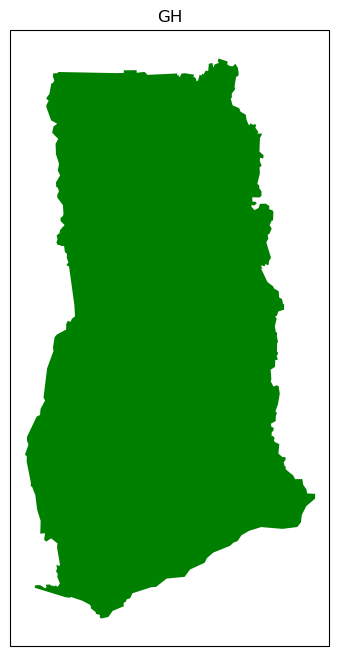

In [50]:
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={"projection": ccrs.EqualEarth(n.buses.x.mean())})
with plt.rc_context({"patch.linewidth": 0.}):
    regions_onshore.plot(
    ax=ax,
    facecolor="green",
    edgecolor="white",
    aspect="equal",
    transform=ccrs.PlateCarree(),
    linewidth=0,
    )
ax.set_title(", ".join(regions_onshore.name.values))

Component check

In [51]:
for c in n.iterate_components(list(n.components.keys())[2:]):
    print("Component '{}' has {} entries".format(c.name,len(c.df)))

Component 'Bus' has 36 entries
Component 'Carrier' has 18 entries
Component 'GlobalConstraint' has 1 entries
Component 'Line' has 16 entries
Component 'LineType' has 34 entries
Component 'TransformerType' has 14 entries
Component 'Link' has 48 entries
Component 'Load' has 12 entries
Component 'Generator' has 66 entries
Component 'StorageUnit' has 2 entries
Component 'Store' has 24 entries


Snapshot check

In [52]:
print(n.snapshots)
print(f"Time steps: " + str(len(n.snapshots)))

DatetimeIndex(['2013-01-01 00:00:00', '2013-01-01 03:00:00',
               '2013-01-01 06:00:00', '2013-01-01 09:00:00',
               '2013-01-01 12:00:00', '2013-01-01 15:00:00',
               '2013-01-01 18:00:00', '2013-01-01 21:00:00',
               '2013-01-02 00:00:00', '2013-01-02 03:00:00',
               ...
               '2013-12-30 18:00:00', '2013-12-30 21:00:00',
               '2013-12-31 00:00:00', '2013-12-31 03:00:00',
               '2013-12-31 06:00:00', '2013-12-31 09:00:00',
               '2013-12-31 12:00:00', '2013-12-31 15:00:00',
               '2013-12-31 18:00:00', '2013-12-31 21:00:00'],
              dtype='datetime64[ns]', name='snapshot', length=2920, freq=None)
Time steps: 2920


## Analyse energy system

Analyse the current capacity of the energy system - map view

/home/marco-s/miniconda3/envs/pypsa-earth-2/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


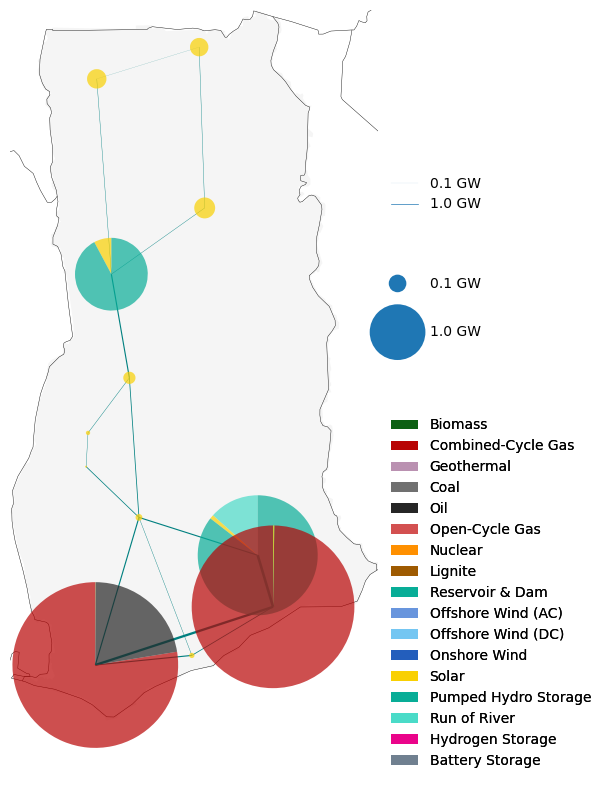

In [53]:
# Scale settings
bus_scale = 3e3 
line_scale = 2e3

# Legend settings
bus_sizes = [100, 1000]  # in MW
line_sizes = [100, 1000]  # in MW

# n-noLoad = n.carriers.drop("Load", inplace=False)
n.carriers.drop("Load", inplace=True)

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={"projection": ccrs.EqualEarth(n.buses.x.mean())})
gen = n.generators[(n.generators.carrier != "load") & (n.generators.carrier != "export")].groupby(["bus", "carrier"]).p_nom.sum()
sto = n.storage_units.groupby(["bus", "carrier"]).p_nom.sum()
buses = pd.concat([gen, sto])

with plt.rc_context({"patch.linewidth": 0.}):
    n.plot(
        bus_sizes=buses / bus_scale,
        bus_alpha=0.7,
        line_widths=n.lines.s_nom_opt / line_scale,
        link_widths=n.links[n.links.carrier != "export"].p_nom_opt / line_scale,
        line_colors="teal",
        ax=ax,
        margin=0.1,
        color_geomap=None,
    )
regions_onshore.plot(
    ax=ax,
    facecolor="whitesmoke",
    edgecolor="white",
    aspect="equal",
    transform=ccrs.PlateCarree(),
    linewidth=0,
)
ax.set_extent(regions_onshore.total_bounds[[0, 2, 1, 3]])

# Make more space at bottom to not cut off capacity circle
ylims = ax.get_ylim()  # Get current y-axis limits
ax.set_ylim(ylims[0] - 0.7e5, ylims[1])  # Extend the bottom by shifting downward

legend_kwargs = {"loc": "upper left", "frameon": False}
legend_circles_dict = {"bbox_to_anchor": (1, 0.67), "labelspacing": 2.5, **legend_kwargs}

add_legend_circles(
    ax,
    [s / bus_scale for s in bus_sizes],
    [f"{s / 1000} GW" for s in bus_sizes],
    legend_kw=legend_circles_dict,    
)
add_legend_lines(
    ax,
    [s / line_scale for s in line_sizes],
    [f"{s / 1000} GW" for s in line_sizes],
    legend_kw={"bbox_to_anchor": (1, 0.8), **legend_kwargs},
)
add_legend_patches(
    ax,
    n.carriers.color,
    n.carriers.nice_name,
    legend_kw={"bbox_to_anchor": (1, 0), **legend_kwargs, "loc":"lower left"},
)
fig.tight_layout()
fig.savefig("brownfield_capacities_" + scenario_name + ".png", bbox_inches="tight", dpi=300)

Analyse the current generation capacity of the energy system - pie chart view

Text(0.5, 1.0, 'Generator Capacity by Carrier')

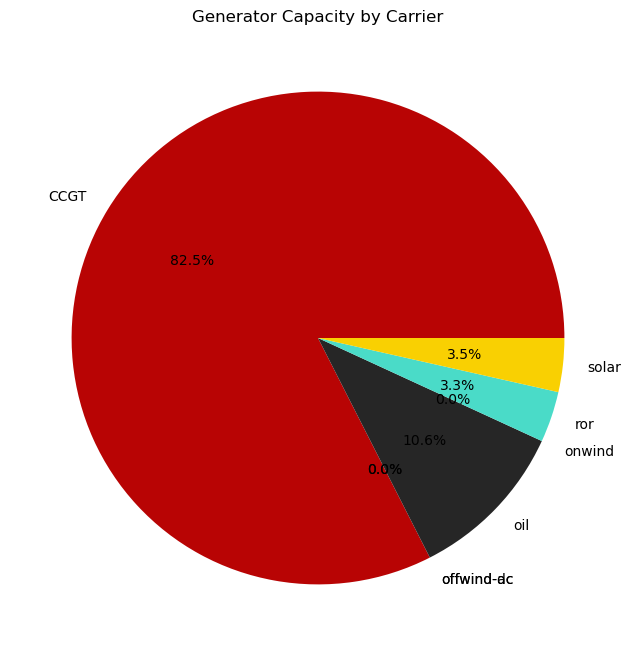

In [54]:
generator_capacity_by_carrier = n.generators[(n.generators.carrier != "load") & (n.generators.carrier != "export")].groupby(["carrier"]).p_nom.sum()
plt.figure(figsize=(8, 8))
plt.pie(generator_capacity_by_carrier, labels=generator_capacity_by_carrier.index, autopct='%1.1f%%', colors=n.carriers[n.carriers.index.isin(generator_capacity_by_carrier.index)].color.reindex(generator_capacity_by_carrier.index))
plt.title("Generator Capacity by Carrier")

Analyse the current gernation capacity of the energy system - tabular view

In [55]:
generator_capacity_by_carrier/1e3 # in GW

carrier
CCGT          3.952155
offwind-ac    0.000000
offwind-dc    0.000000
oil           0.509485
onwind        0.000000
ror           0.160000
solar         0.168954
Name: p_nom, dtype: float64

Analyse the future capacity of the energy system - map view

/home/marco-s/miniconda3/envs/pypsa-earth-2/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


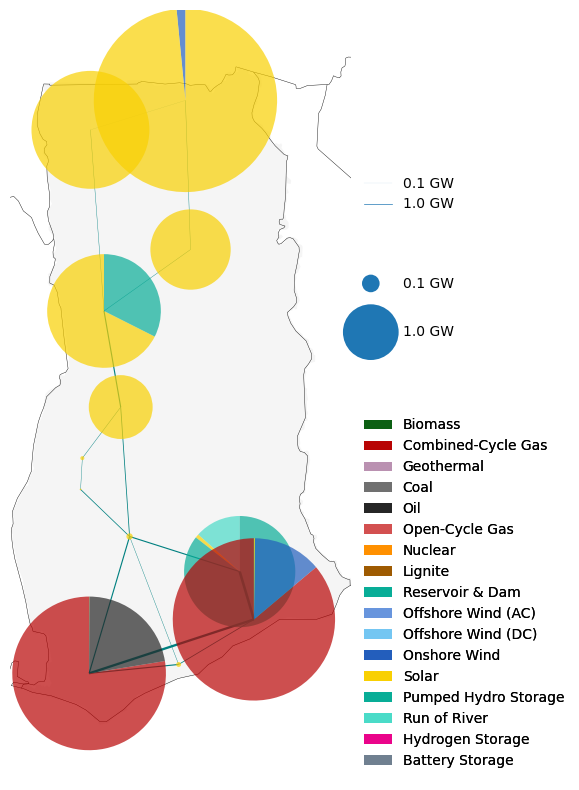

In [56]:
bus_scale = 3e3 
line_scale = 2e3

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={"projection": ccrs.EqualEarth(n.buses.x.mean())})
gen = n.generators[(n.generators.carrier != "load") & (n.generators.carrier != "export")].groupby(["bus", "carrier"]).p_nom_opt.sum()
sto = n.storage_units.groupby(["bus", "carrier"]).p_nom_opt.sum()
buses = pd.concat([gen, sto])

with plt.rc_context({"patch.linewidth": 0.}):
    n.plot(
        bus_sizes=buses / bus_scale,
        bus_alpha=0.7,
        line_widths=n.lines.s_nom_opt / line_scale,
        link_widths=n.links[n.links.carrier != "export"].p_nom_opt / line_scale,
        line_colors="teal",
        ax=ax,
        margin=0.2,
        color_geomap=None,
    )
regions_onshore.plot(
    ax=ax,
    facecolor="whitesmoke",
    edgecolor="white",
    aspect="equal",
    transform=ccrs.PlateCarree(),
    linewidth=0,
)
ax.set_extent(regions_onshore.total_bounds[[0, 2, 1, 3]])

# Make more space at bottom to not cut off capacity circle
ylims = ax.get_ylim()  # Get current y-axis limits
ax.set_ylim(ylims[0] - 0.7e5, ylims[1] + 0.7e5)  # Extend the bottom by shifting downward

legend_kwargs = {"loc": "upper left", "frameon": False}
legend_circles_dict = {"bbox_to_anchor": (1, 0.67), "labelspacing": 2.5, **legend_kwargs}

add_legend_circles(
    ax,
    [s / bus_scale for s in bus_sizes],
    [f"{s / 1000} GW" for s in bus_sizes],
    legend_kw=legend_circles_dict,    
)
add_legend_lines(
    ax,
    [s / line_scale for s in line_sizes],
    [f"{s / 1000} GW" for s in line_sizes],
    legend_kw={"bbox_to_anchor": (1, 0.8), **legend_kwargs},
)
add_legend_patches(
    ax,
    n.carriers.color,
    n.carriers.nice_name,
    legend_kw={"bbox_to_anchor": (1, 0), **legend_kwargs, "loc":"lower left"},
)
fig.tight_layout()

Calculate emissions of future energy system

In [57]:
#ToDo: Not fully correct - double check
co2_emissions = pd.DataFrame(data=n.carriers[["co2_emissions", "nice_name"]]).set_index("nice_name").squeeze().rename_axis("carrier")

energy_production = n.statistics.energy_balance().Generator.droplevel(1).drop(["load", "export"], errors="ignore")

co2_emissions_technology = energy_production * co2_emissions.loc[energy_production.index] * n.snapshot_weightings.generators[0]
co2_emissions_technology

/tmp/ipykernel_711/272665663.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  co2_emissions_technology = energy_production * co2_emissions.loc[energy_production.index] * n.snapshot_weightings.generators[0]


carrier
Offshore Wind (DC)    0.0
Onshore Wind          0.0
Run of River          0.0
Solar                 0.0
dtype: float64

In [58]:
co2_emissions_sum = co2_emissions_technology.sum()
co2_emissions_sum

0.0

In [59]:
n.global_constraints

,sense,mu,type,investment_period,carrier_attribute,constant
GlobalConstraint,,,,,,
CO2Limit,<=,-7565.995153,primary_energy,NaN,co2_emissions,0.0


In [60]:
# Step 1: Create the links_energy DataFrame with "carrier" and "bus0" columns
links_energy = n.links[["carrier", "bus0"]]

# Step 2: Filter only rows where "carrier" contains 'export'
links_energy = links_energy[links_energy["carrier"].str.contains("export", case=False, na=False)]

# Step 3: Calculate the energy sum for indices that contain 'export'
export_energy = n.links_t.p0.sum()
export_energy = export_energy[export_energy.index.str.contains("export", case=False, na=False)]

# Step 4: Map the energy sum to the correct rows in links_energy based on the index
links_energy["energy"] = links_energy.index.map(export_energy)

# Step 5: Group by "bus0" and "carrier" and sum the "energy" values
links_energy_grouped = links_energy.groupby(["bus0", "carrier"], as_index=False)["energy"].sum()

# Display the result
links_energy_grouped


,bus0,carrier,energy


In [61]:
n.loads_t.p["Electricity export load"].sum()*144

KeyError: 'Electricity export load'

In [ ]:
links_energy_grouped.energy.sum()*144

0

ValueError: zero-size array to reduction operation minimum which has no identity

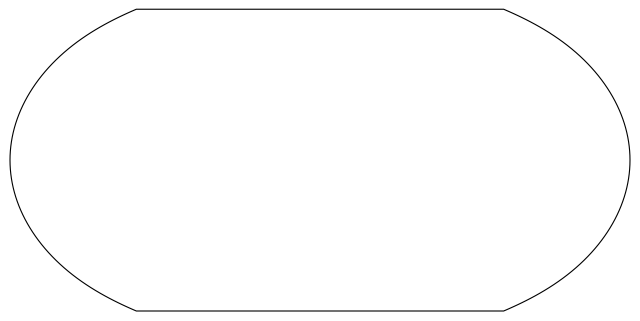

In [ ]:
# Set color
n.carriers.loc["export", "color"] = "#800080"
n.carriers.loc["export", "nice_name"] = "Export"

# Scale settings
bus_scale = 1e5
line_scale = 3e5

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={"projection": ccrs.EqualEarth(n.buses.x.mean())})
export = links_energy_grouped[links_energy_grouped.carrier == "export"].groupby(["bus0", "carrier"]).energy.sum()
buses = pd.concat([export])

with plt.rc_context({"patch.linewidth": 0.}):
    n.plot(
        bus_sizes=buses / bus_scale,
        bus_alpha=0.7,
        line_widths=n.lines.s_nom_opt / line_scale,
        link_widths=n.links.p_nom_opt / line_scale,
        line_colors="teal",
        ax=ax,
        margin=0.2,
        color_geomap=None,
    )
regions_onshore.plot(
    ax=ax,
    facecolor="whitesmoke",
    edgecolor="white",
    aspect="equal",
    transform=ccrs.PlateCarree(),
    linewidth=0,
)
ax.set_extent(regions_onshore.total_bounds[[0, 2, 1, 3]])
legend_kwargs = {"loc": "upper left", "frameon": False}
legend_circles_dict = {"bbox_to_anchor": (1, 0.67), "labelspacing": 2.5, **legend_kwargs}

add_legend_circles(
    ax,
    [s / bus_scale for s in bus_sizes],
    [f"{s / 1000} GW" for s in bus_sizes],
    legend_kw=legend_circles_dict,    
)
add_legend_lines(
    ax,
    [s / line_scale for s in line_sizes],
    [f"{s / 1000} GW" for s in line_sizes],
    legend_kw={"bbox_to_anchor": (1, 0.8), **legend_kwargs},
)
add_legend_patches(
    ax,
    n.carriers.color.loc["export"],
    n.carriers.nice_name.loc["export"],
    legend_kw={"bbox_to_anchor": (1, 0), **legend_kwargs, "loc":"lower left"},
)
fig.tight_layout()

Analys the future generation capacity expansion of the energy system - bar chart

In [ ]:
generation_capacity_expansion = n.statistics.optimal_capacity(comps=["Generator"]).droplevel(0).div(1e3)-n.statistics.installed_capacity(comps=["Generator"]).droplevel(0).div(1e3)
generation_capacity_expansion

carrier
Combined-Cycle Gas     0.00000
Offshore Wind (DC)         NaN
Oil                    0.00000
Onshore Wind               NaN
Run of River           0.00000
Solar                 11.83384
load                   0.00000
dtype: float64

Plot the future generation capacity expansion of the energy system - tabular chart

<AxesSubplot:title={'center':'Generator capacity expansion in GW'}, xlabel='carrier'>

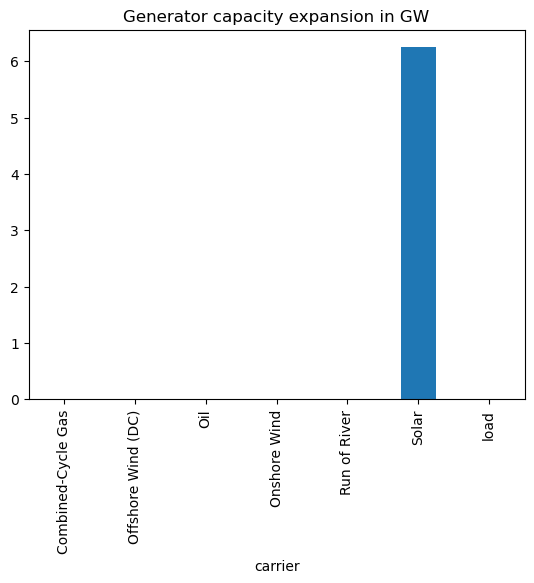

In [62]:
generation_capacity_expansion = n.statistics.optimal_capacity(comps=["Generator"]).droplevel(0).div(1e3)-n.statistics.installed_capacity(comps=["Generator"]).droplevel(0).div(1e3)
generation_capacity_expansion.plot.bar(title="Generator capacity expansion in GW")

Analyse the future energy generation of the energy system - bar chart view

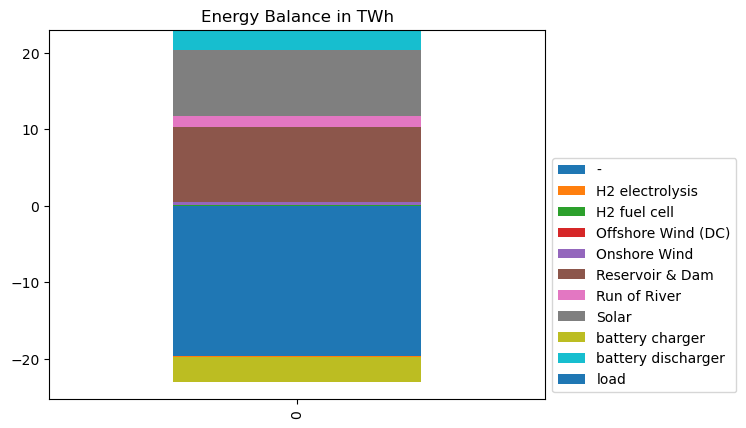

In [63]:
fig, ax = plt.subplots()
color_setting = n.carriers.set_index(n.carriers.nice_name)
energy_balance = n.statistics.energy_balance().loc[:, :, "AC"].groupby("carrier").sum().div(1e6).to_frame().T
energy_balance.plot.bar(stacked=True, ax=ax, title="Energy Balance in TWh")
n.carriers[n.carriers.index.isin(generator_capacity_by_carrier.index)].color.reindex(generator_capacity_by_carrier.index)

ax.legend(bbox_to_anchor=(1, 0), loc="lower left", title=None, ncol=1)

Analyse the future energy generation of the energy system - tabular view

In [64]:
n.statistics.energy_balance()/1e6 # In TWh

component    carrier             bus_carrier
Link         H2 electrolysis     AC            -1.650885e-01
             H2 fuel cell        H2            -1.320708e-01
             battery charger     AC            -3.189087e+00
             battery discharger  battery       -2.870178e+00
             H2 electrolysis     H2             1.320708e-01
             H2 fuel cell        AC             7.660108e-02
             battery charger     battery        2.870178e+00
             battery discharger  AC             2.583161e+00
Load         -                   AC            -1.965415e+01
Generator    Offshore Wind (DC)  AC             2.468100e-08
             Onshore Wind        AC             4.178441e-01
             Run of River        AC             1.401600e+00
             Solar               AC             8.725121e+00
             load                AC             4.865928e-10
                                 H2             4.860904e-10
                                 battery

## Analyse pv and wind potential - map view

In [ ]:
solar = xr.open_dataset(solar_path)
wind = xr.open_dataset(onwind_path)

def plot_voronoi(n, carrier, voronoi, cmap, projection, title=None, filename=None):
    g = n.generators.loc[n.generators.carrier == carrier]
    # br = gpd.read_file(f"resources/{scenario_name}/bus_regions/regions_{voronoi}.geojson").set_index("name")
    br = gpd.read_file(PARENT + f"resources/{scenario_name}/bus_regions/regions_{voronoi}.geojson").set_index("name")
    br_area = br.to_crs("ESRI:54009")
    br_area = br_area.geometry.area * 1e-6
    br["p_nom_max"] = g.groupby("bus").sum().p_nom_max / br_area

    fig, ax = plt.subplots(figsize=(8, 4), subplot_kw={"projection": projection})
    plt.rcParams.update({"font.size": 10})
    br.plot(
        ax=ax,
        column="p_nom_max",
        transform=ccrs.PlateCarree(),
        linewidth=0.25,
        edgecolor="k",
        cmap=cmap,
        vmin=0,
        vmax=br["p_nom_max"].max(),
        legend=True,
        legend_kwds={"label": r"potential density"},
    )
    ax.coastlines()
    ax.add_feature(cartopy.feature.BORDERS.with_scale("110m"))
    ax.set_extent(country_coordinates, crs=ccrs.PlateCarree()) 
    
    if title is not None:
        plt.title(title)

Plot pv energy potential

INFO:pypsa.io:Imported network elec.nc has buses, carriers, generators, lines, loads, storage_units, transformers


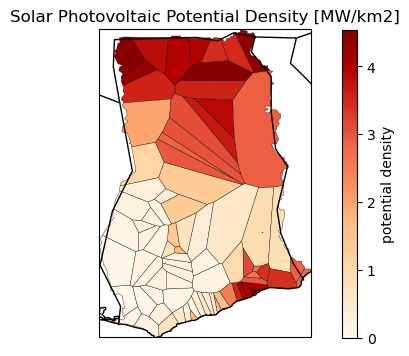

In [ ]:
warnings.simplefilter(action='ignore', category=FutureWarning)
plot_voronoi(
    pypsa.Network(network_path),
    "solar",
    "onshore",
    "OrRd",
    ccrs.PlateCarree(),
    title="Solar Photovoltaic Potential Density [MW/km2]",
)
warnings.simplefilter(action='default', category=FutureWarning)

Plot wind energy potential

INFO:pypsa.io:Imported network elec.nc has buses, carriers, generators, lines, loads, storage_units, transformers


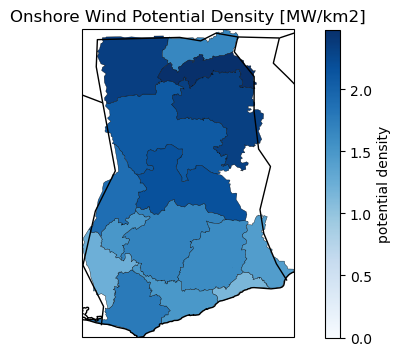

In [65]:
warnings.simplefilter(action='ignore', category=FutureWarning)
plot_voronoi(
    pypsa.Network(network_path),
    "onwind",
    "onshore",
    "Blues",
    ccrs.PlateCarree(),
    title="Onshore Wind Potential Density [MW/km2]",
)
warnings.simplefilter(action='default', category=FutureWarning)

Levelized cost of electricity

In [ ]:
# Calculation levelzied cost of electricity in €/MWh based on overall costs and electricity generation
# n.statistics.market_value() ?
lcoe = n.objective/n.statistics.energy_balance().Generator.sum()
lcoe 

57.81961092219983

In [ ]:
# Calculation levelzied cost of electricity in €/MWh based on overall costs and electricity demand
lcoe = n.objective/n.statistics.energy_balance().Load.sum()*(-1)
lcoe 

49.09788129039497

In [ ]:
n.statistics.market_value()

component    carrier           
Generator    Offshore Wind (DC)     95.198294
             Onshore Wind          100.584705
             Run of River           86.801010
             Solar                  39.941792
             load                   77.078463
Line         AC                      0.483481
Link         H2 electrolysis        30.109137
             H2 fuel cell           12.502884
             battery charger        18.867411
             battery discharger      0.102462
Load         -                            NaN
StorageUnit  Reservoir & Dam       112.445962
Store        Battery Storage        45.786660
             Hydrogen Storage        3.536274
dtype: float64

Check storages

In [ ]:
n.storage_units

,carrier,bus,p_nom,max_hours,p_min_pu,efficiency_dispatch,efficiency_store,cyclic_state_of_charge,control,marginal_cost,...,marginal_cost_quadratic,capital_cost,build_year,lifetime,state_of_charge_initial,state_of_charge_initial_per_period,state_of_charge_set,cyclic_state_of_charge_per_period,standing_loss,inflow
StorageUnit,,,,,,,,,,,,,,,,,,,,,
GH0 3 hydro,hydro,GH0 3,1020.0,39411.788515,0.0,0.9,0.0,True,,0.009920,...,0.0,0.0,0,inf,0.0,False,NaN,True,0.0,0.0
GH0 8 hydro,hydro,GH0 8,404.0,39411.788515,0.0,0.9,0.0,True,,0.010793,...,0.0,0.0,0,inf,0.0,False,NaN,True,0.0,0.0


## Additional input (Marco)

In [ ]:
CCGT_col = [col for col in n.generators_t.p.columns if 'CCGT' in col]
n.generators_t.p[CCGT_col].sum()

Generator
GH0 4 CCGT    0.0
GH0 7 CCGT    0.0
dtype: float64

In [ ]:
n.generators_t.p.columns

Index(['GH0 0 H2 load', 'GH0 0 battery load', 'GH0 0 load', 'GH0 0 onwind',
       'GH0 0 solar', 'GH0 1 H2 load', 'GH0 1 battery load', 'GH0 1 load',
       'GH0 1 offwind-ac', 'GH0 1 offwind-dc', 'GH0 1 onwind', 'GH0 1 solar',
       'GH0 10 H2 load', 'GH0 10 battery load', 'GH0 10 load', 'GH0 10 onwind',
       'GH0 10 solar', 'GH0 11 H2 load', 'GH0 11 battery load', 'GH0 11 load',
       'GH0 11 offwind-ac', 'GH0 11 offwind-dc', 'GH0 11 onwind',
       'GH0 11 solar', 'GH0 12 H2 load', 'GH0 12 battery load', 'GH0 12 load',
       'GH0 12 onwind', 'GH0 12 solar', 'GH0 13 H2 load',
       'GH0 13 battery load', 'GH0 13 load', 'GH0 13 onwind', 'GH0 13 solar',
       'GH0 14 H2 load', 'GH0 14 battery load', 'GH0 14 load', 'GH0 14 onwind',
       'GH0 14 solar', 'GH0 15 H2 load', 'GH0 15 battery load', 'GH0 15 load',
       'GH0 15 onwind', 'GH0 15 solar', 'GH0 2 H2 load', 'GH0 2 battery load',
       'GH0 2 load', 'GH0 2 onwind', 'GH0 2 solar', 'GH0 3 H2 load',
       'GH0 3 battery lo

In [ ]:
n.generators_t.p

Generator,GH0 0 H2 load,GH0 0 battery load,GH0 0 load,GH0 0 onwind,GH0 0 solar,GH0 1 H2 load,GH0 1 battery load,GH0 1 load,GH0 1 offwind-ac,GH0 1 offwind-dc,...,GH0 8 H2 load,GH0 8 battery load,GH0 8 load,GH0 8 onwind,GH0 8 solar,GH0 9 H2 load,GH0 9 battery load,GH0 9 load,GH0 9 onwind,GH0 9 solar
snapshot,,,,,,,,,,,,,,,,,,,,,
2013-01-01 00:00:00,0.000005,0.000005,0.000005,0.000046,0.000000,0.000005,0.000005,0.000005,0.0,0.000000,...,0.000005,0.000005,0.000005,0.000012,0.000000,0.000005,0.000005,0.000005,0.000000e+00,0.000000
2013-01-01 03:00:00,0.000005,0.000005,0.000005,0.000036,0.000000,0.000005,0.000005,0.000005,0.0,0.000000,...,0.000005,0.000005,0.000005,0.000013,0.000000,0.000005,0.000005,0.000005,0.000000e+00,0.000000
2013-01-01 06:00:00,0.000005,0.000005,0.000005,0.000028,38.322103,0.000005,0.000005,0.000005,0.0,0.000000,...,0.000005,0.000005,0.000005,0.000010,0.122952,0.000005,0.000005,0.000005,0.000000e+00,0.013750
2013-01-01 09:00:00,0.000005,0.000005,0.000005,0.000014,306.432228,0.000005,0.000005,0.000005,0.0,0.000000,...,0.000005,0.000005,0.000005,0.000004,1.075409,0.000005,0.000005,0.000005,2.791915e-07,0.101130
2013-01-01 12:00:00,0.000005,0.000005,0.000005,0.000006,380.095356,0.000005,0.000005,0.000005,0.0,0.000000,...,0.000005,0.000005,0.000005,0.000002,1.515718,0.000005,0.000005,0.000005,0.000000e+00,0.157560
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2013-12-31 09:00:00,0.000005,0.000005,0.000005,0.000000,294.341715,0.000005,0.000005,0.000005,0.0,0.000005,...,0.000005,0.000005,0.000005,0.000002,1.069619,0.000005,0.000005,0.000005,8.059214e-07,0.077843
2013-12-31 12:00:00,0.000005,0.000005,0.000005,0.000000,334.545376,0.000005,0.000005,0.000005,0.0,0.000004,...,0.000005,0.000005,0.000005,0.000000,1.270238,0.000005,0.000005,0.000005,0.000000e+00,0.101278
2013-12-31 15:00:00,0.000005,0.000005,0.000005,0.000000,212.114254,0.000005,0.000005,0.000005,0.0,0.000002,...,0.000005,0.000005,0.000005,0.000000,0.786124,0.000005,0.000005,0.000005,7.119671e-07,0.083342


In [ ]:
import re

df = n.generators_t.p

# Extract the category (everything after "GH0 <number> ")
categories = [re.sub(r'GH0 \d+ ', '', col) for col in df.columns]

# Create a mapping from the original column names to their categories
column_mapping = dict(zip(df.columns, categories))

# Group by category
grouped = {}
for col, category in column_mapping.items():
    grouped.setdefault(category, []).append(col)

# Print grouped columns
for category, cols in grouped.items():
    print(f"{category}: {cols}")

print(grouped)

H2 load: ['GH0 0 H2 load', 'GH0 1 H2 load', 'GH0 10 H2 load', 'GH0 11 H2 load', 'GH0 12 H2 load', 'GH0 13 H2 load', 'GH0 14 H2 load', 'GH0 15 H2 load', 'GH0 2 H2 load', 'GH0 3 H2 load', 'GH0 4 H2 load', 'GH0 5 H2 load', 'GH0 6 H2 load', 'GH0 7 H2 load', 'GH0 8 H2 load', 'GH0 9 H2 load']
battery load: ['GH0 0 battery load', 'GH0 1 battery load', 'GH0 10 battery load', 'GH0 11 battery load', 'GH0 12 battery load', 'GH0 13 battery load', 'GH0 14 battery load', 'GH0 15 battery load', 'GH0 2 battery load', 'GH0 3 battery load', 'GH0 4 battery load', 'GH0 5 battery load', 'GH0 6 battery load', 'GH0 7 battery load', 'GH0 8 battery load', 'GH0 9 battery load']
load: ['GH0 0 load', 'GH0 1 load', 'GH0 10 load', 'GH0 11 load', 'GH0 12 load', 'GH0 13 load', 'GH0 14 load', 'GH0 15 load', 'GH0 2 load', 'GH0 3 load', 'GH0 4 load', 'GH0 5 load', 'GH0 6 load', 'GH0 7 load', 'GH0 8 load', 'GH0 9 load']
onwind: ['GH0 0 onwind', 'GH0 1 onwind', 'GH0 10 onwind', 'GH0 11 onwind', 'GH0 12 onwind', 'GH0 13 on

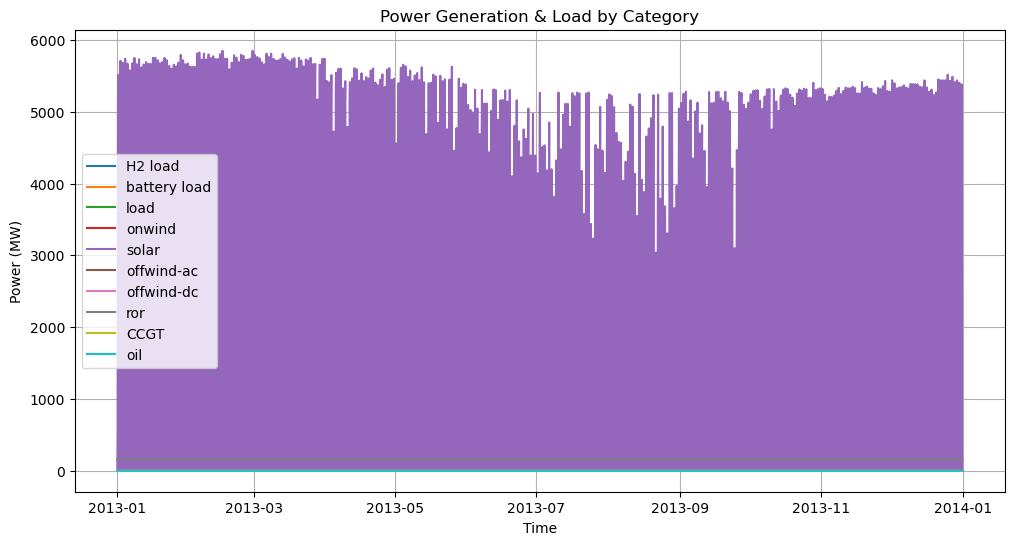

In [ ]:
import pandas as pd
import re
import matplotlib.pyplot as plt


# Step 1: Extract category names
categories = [re.sub(r'GH0 \d+ ', '', col) for col in df.columns]

# Step 2: Create a mapping from category name to a list of columns
category_columns = {}
for col, category in zip(df.columns, categories):
    if category not in category_columns:
        category_columns[category] = []
    category_columns[category].append(col)

# Step 3: Sum data for each category and create a new DataFrame
grouped_data = pd.DataFrame({category: df[cols].sum(axis=1) for category, cols in category_columns.items()})

# Step 4: Plot the grouped time series
plt.figure(figsize=(12, 6))
for category in grouped_data.columns:
    plt.plot(grouped_data.index, grouped_data[category], label=category, linestyle="-")

# Formatting the plot
plt.xlabel("Time")
plt.ylabel("Power (MW)")  # Adjust based on your data units
plt.title("Power Generation & Load by Category")
plt.legend()
plt.grid(True)
plt.show()


Total load in 2013: 19.65415246474686 TWh


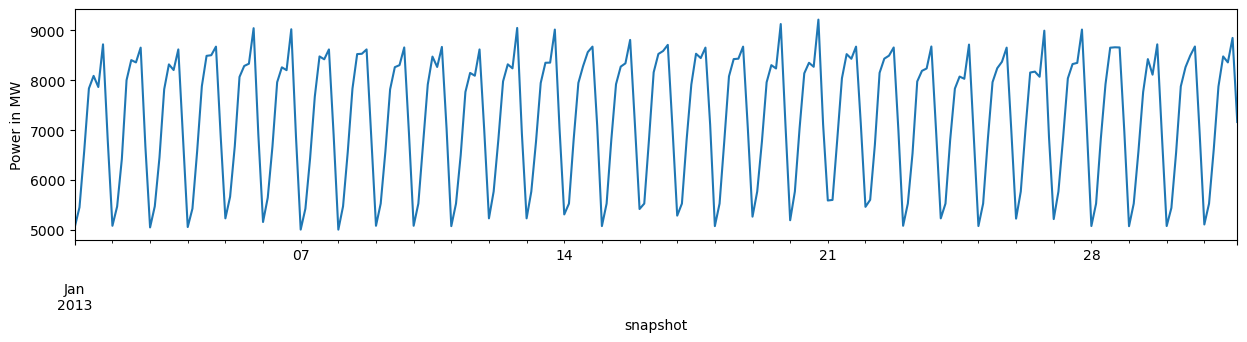

In [ ]:
loads = n.loads_t.p.multiply(n.snapshot_weightings.generators, axis=0)
fig, ax = plt.subplots(figsize=(15, 3))
loads.sum(axis=1).loc['2013-01-01':'2013-01-31'].plot(ax=ax)
ax.set_ylabel('Power in MW')
print('Total load in 2013: {} TWh'.format(n.loads_t.p.multiply(n.snapshot_weightings.generators, axis=0).sum(axis=1).sum() / 1000000))

<AxesSubplot:xlabel='snapshot'>

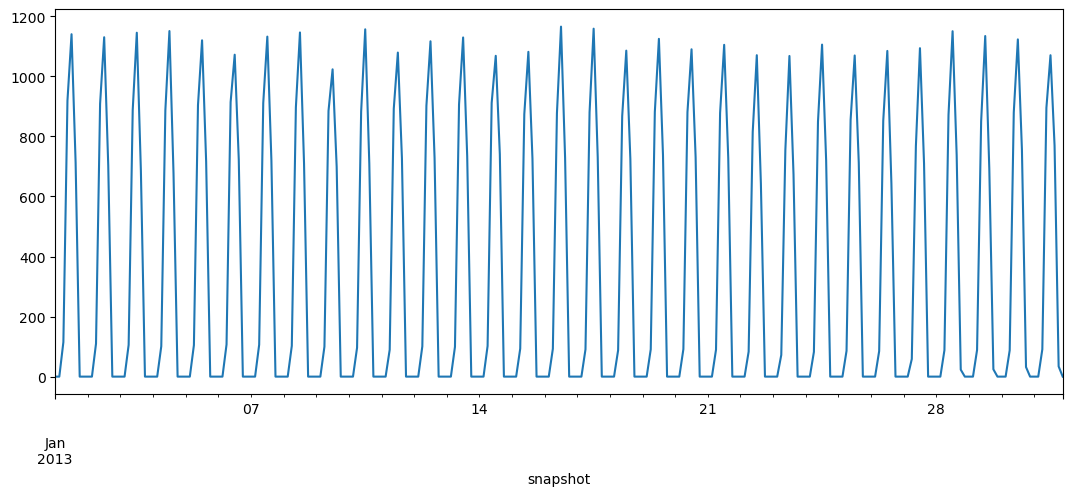

In [ ]:
n.generators_t.p.multiply(n.snapshot_weightings.generators, axis=0).loc["2013-01-01":"2013-01-31", "GH0 0 solar"].plot(figsize=(13,5))

In [ ]:
n.objective / 1e9 # billion europs p.a.
print("The total system cost is {:.0f} million euros per year".format(n.objective / 1e6))

The total system cost is 965 million euros per year


## Line expansion

<AxesSubplot:xlabel='Line'>

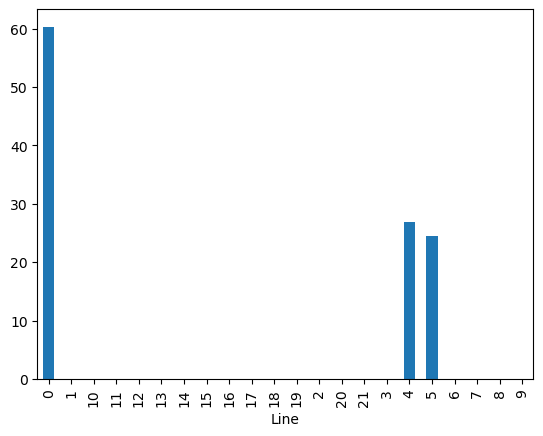

In [ ]:
(n.lines.s_nom_opt - n.lines.s_nom).plot.bar()

Text(0, 0.5, 'Capacity in GW')

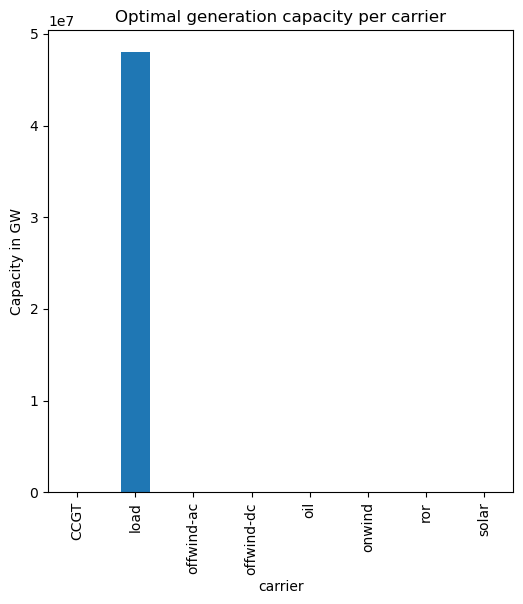

In [ ]:
fig, ax = plt.subplots(figsize=(6,6))
n.generators.groupby('carrier').p_nom_opt.sum().multiply(1e-3).plot.bar(ax = ax)
ax.set_title('Optimal generation capacity per carrier')
ax.set_ylabel('Capacity in GW')

In [ ]:
# n.generators.drop(n.generators[n.generators['carrier'] == 'load'], inplace=True)
n.generators = n.generators[n.generators['carrier'] != 'load']

In [ ]:
n.storage_units.groupby('carrier').p_nom_opt.sum() / 1e3 # GW

carrier
hydro    1.424
Name: p_nom_opt, dtype: float64

<AxesSubplot:xlabel='snapshot'>

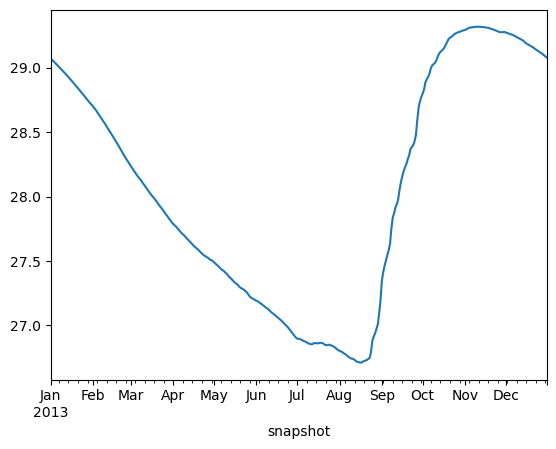

In [ ]:
(n.storage_units_t.state_of_charge.sum(axis=1).resample('D').mean() / 1e6).plot()

In [ ]:
n.storage_units_t.state_of_charge / 1e6

StorageUnit,GH0 3 hydro,GH0 8 hydro
snapshot,,
2013-01-01 00:00:00,21.019326,8.053581
2013-01-01 03:00:00,21.017716,8.053551
2013-01-01 06:00:00,21.015959,8.053522
2013-01-01 09:00:00,21.016479,8.053546
2013-01-01 12:00:00,21.016999,8.053571
...,...,...
2013-12-31 09:00:00,21.024705,8.054086
2013-12-31 12:00:00,21.025227,8.054110
2013-12-31 15:00:00,21.025747,8.054133


In [ ]:
n.storage_units

,carrier,bus,p_nom,max_hours,p_min_pu,efficiency_dispatch,efficiency_store,cyclic_state_of_charge,control,marginal_cost,...,marginal_cost_quadratic,capital_cost,build_year,lifetime,state_of_charge_initial,state_of_charge_initial_per_period,state_of_charge_set,cyclic_state_of_charge_per_period,standing_loss,inflow
StorageUnit,,,,,,,,,,,,,,,,,,,,,
GH0 3 hydro,hydro,GH0 3,1020.0,39411.788515,0.0,0.9,0.0,True,,0.009920,...,0.0,0.0,0,inf,0.0,False,NaN,True,0.0,0.0
GH0 8 hydro,hydro,GH0 8,404.0,39411.788515,0.0,0.9,0.0,True,,0.010793,...,0.0,0.0,0,inf,0.0,False,NaN,True,0.0,0.0


In [ ]:
n.generators.groupby(["bus", "carrier"]).p_nom_opt.sum()

bus     carrier   
GH0 0   onwind           0.000136
        solar          702.843548
GH0 1   offwind-ac       0.000000
        offwind-dc       0.000047
        onwind           0.000096
        solar         1860.503685
GH0 10  onwind           0.000134
        solar         1928.047660
GH0 11  offwind-ac       0.000000
        offwind-dc       0.000047
        onwind           0.000069
        solar            0.234235
GH0 12  onwind           0.000162
        solar         2922.878244
GH0 13  onwind           0.000052
        solar            1.192719
GH0 14  onwind           0.000072
        solar            3.352676
GH0 15  onwind           0.000074
        solar         2540.470289
GH0 2   onwind           0.000073
        solar            0.804166
GH0 3   offwind-ac       0.000000
        offwind-dc       0.000046
        onwind           0.000076
        ror            160.000000
        solar            7.612979
GH0 4   CCGT          1765.000000
        offwind-ac       0.00

In [ ]:
n.storage_units_t.p_store.multiply(n.snapshot_weightings.generators, axis=0).loc['2013-02-01':'2013-02-07'].plot.line(linestyle='-')

TypeError: no numeric data to plot

Text(0.5, 1.0, 'State of charge in TWh')

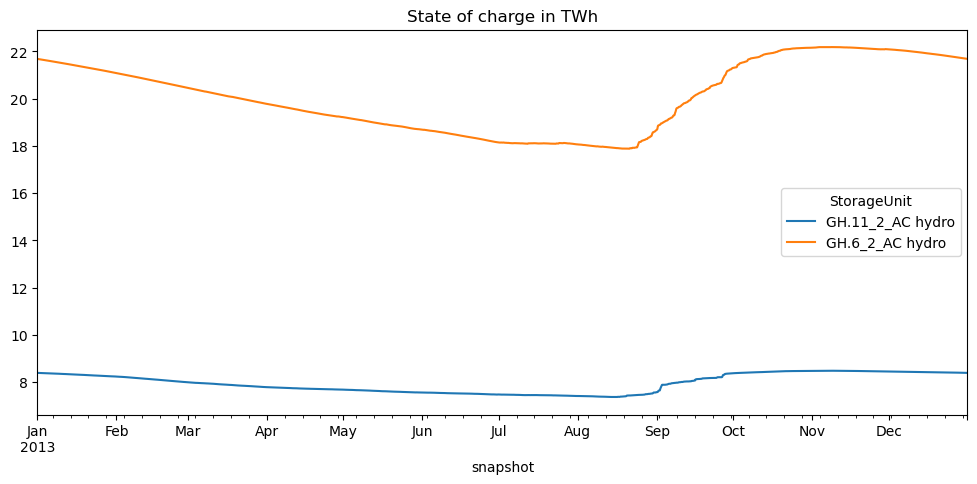

In [ ]:
fig, ax = plt.subplots(figsize=(12,5))
(n.storage_units_t.state_of_charge / 1e6).plot(ax = ax)
ax.set_title('State of charge in TWh')

In [ ]:
(n.storage_units_t.state_of_charge / 1e6)

StorageUnit,GH.11_2_AC hydro,GH.6_2_AC hydro
snapshot,,
2013-01-01 00:00:00,8.391954,21.679632
2013-01-01 03:00:00,8.391499,21.677255
2013-01-01 06:00:00,8.390738,21.674868
2013-01-01 09:00:00,8.390878,21.673287
2013-01-01 12:00:00,8.391018,21.671705
...,...,...
2013-12-31 09:00:00,8.393850,21.689349
2013-12-31 12:00:00,8.393993,21.688503
2013-12-31 15:00:00,8.394135,21.686788


<AxesSubplot:xlabel='snapshot'>

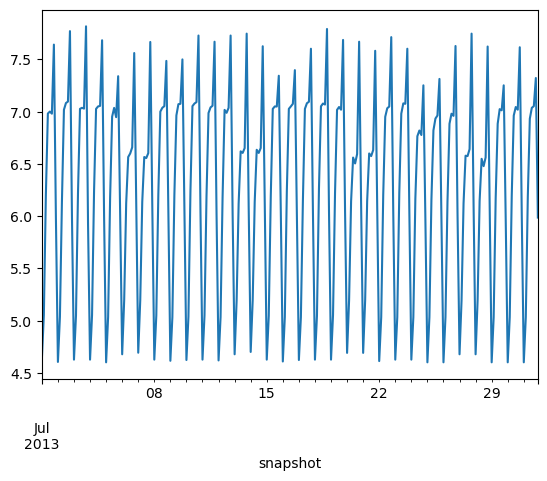

In [ ]:
(n.loads_t.p.sum(axis=1).multiply(n.snapshot_weightings.generators) / 1e3).loc['2013-07'].plot()

<AxesSubplot:xlabel='snapshot'>

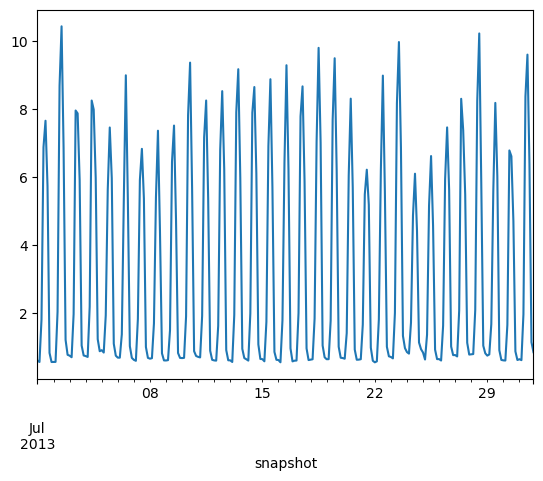

In [ ]:
(n.generators_t.p.sum(axis=1).multiply(n.snapshot_weightings.generators) / 1e3).loc['2013-07'].plot()

In [ ]:
gen_snap = n.generators_t.p.loc['2013-01-01 18:00:00']
gen_snap

Generator
GH.11_2_AC H2 load         0.000005
GH.11_2_AC battery load    0.000005
GH.11_2_AC load            0.000005
GH.11_2_AC onwind          0.000005
GH.11_2_AC solar           0.000000
                             ...   
GH.9_2_AC H2 load          0.000005
GH.9_2_AC battery load     0.000005
GH.9_2_AC load             0.000005
GH.9_2_AC onwind           0.000017
GH.9_2_AC solar            0.000000
Name: 2013-01-01 18:00:00, Length: 66, dtype: float64

<AxesSubplot:xlabel='snapshot'>

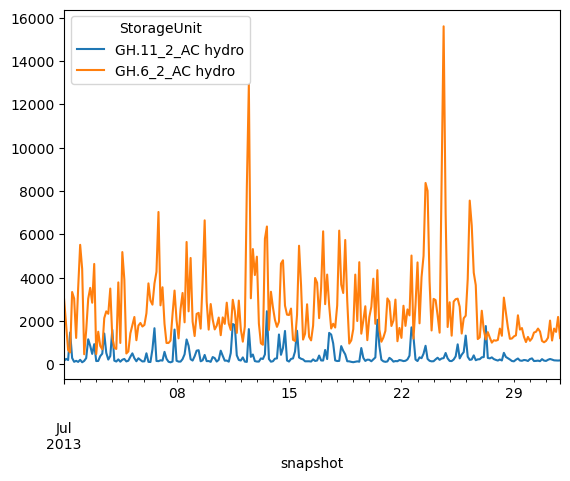

In [ ]:
n.storage_units_t.inflow.multiply(n.snapshot_weightings.generators, axis=0).loc['2013-07'].plot()

In [ ]:
n.statistics.capacity_factor(comps=["Generator", "StorageUnit"]).round(2)

component    carrier           
Generator    Offshore Wind (DC)    0.06
             Onshore Wind          0.12
             Run of River          1.00
             Solar                 0.16
StorageUnit  Reservoir & Dam       0.79
dtype: float64

In [ ]:
n.statistics.supply().loc["StorageUnit"] / 1e6 # from MWh to TWh

carrier
Reservoir & Dam    9.804002
dtype: float64

In [66]:
n.statistics.dispatch(comps=["Generator", "StorageUnit"]).round(2) / 1e6

/tmp/ipykernel_711/2211605357.py:1: DeprecatedWarning: dispatch is deprecated as of 0.28 and will be removed in 0.29. Use 'energy_balance' instead.
  n.statistics.dispatch(comps=["Generator", "StorageUnit"]).round(2) / 1e6


component    carrier           
Generator    Offshore Wind (DC)    2.000000e-08
             Onshore Wind          4.178441e-01
             Run of River          1.401600e+00
             Solar                 8.725121e+00
             load                  0.000000e+00
StorageUnit  Reservoir & Dam       9.804002e+00
dtype: float64

In [67]:
n.storage_units_t.inflow.sum(axis=0) / 1e6 # TWh

StorageUnit
GH.11_2_AC hydro    0.622708
GH.6_2_AC hydro     3.008404
dtype: float64

In [68]:
n.storage_units_t.p.sum(axis=0) / 1e6 * 3 # TWh

StorageUnit
GH.11_2_AC hydro    1.681311
GH.6_2_AC hydro     8.122690
dtype: float64

In [ ]:
n.storage_units_t.spill.sum(axis=0) / 1e6

StorageUnit
GH.11_2_AC hydro    4.218251e-07
GH.6_2_AC hydro     6.328215e-07
dtype: float64

In [69]:
n.statistics.supply() / 1e6

component    carrier           
Line         AC                    2.934657e+01
Link         H2 electrolysis       1.320708e-01
             H2 fuel cell          7.660108e-02
             battery charger       2.870178e+00
             battery discharger    2.583161e+00
Generator    Offshore Wind (DC)    2.468100e-08
             Onshore Wind          4.178441e-01
             Run of River          1.401600e+00
             Solar                 8.725121e+00
             load                  1.458905e-09
Store        Battery Storage       2.870163e+00
             Hydrogen Storage      1.320639e-01
StorageUnit  Reservoir & Dam       9.804002e+00
dtype: float64

In [ ]:
hydro_storage = n.storage_units["p_nom"] * n.storage_units["max_hours"] / 1e6 # TWh
print(hydro_storage)

StorageUnit
GH.11_2_AC hydro    15.922363
GH.6_2_AC hydro     40.200024
dtype: float64


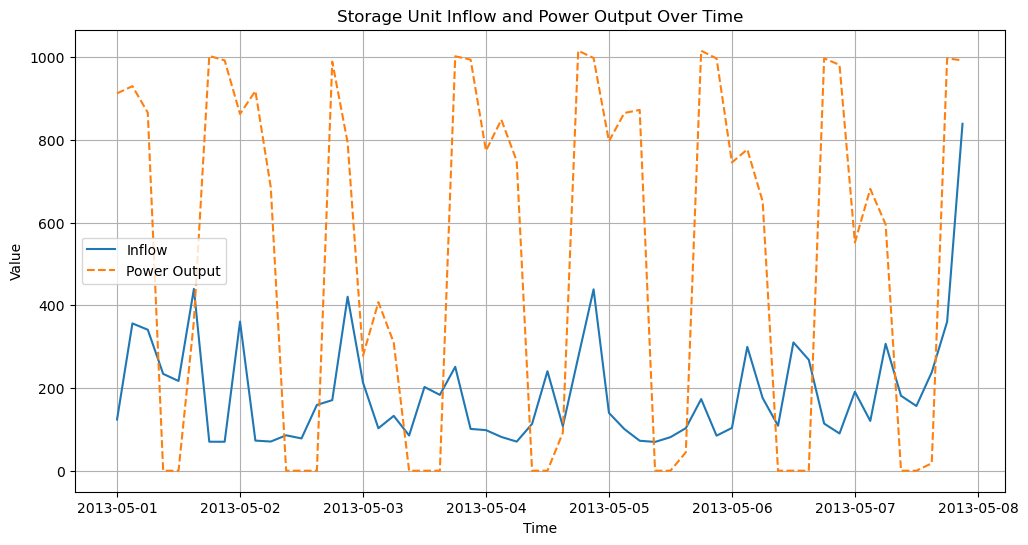

In [ ]:
n.storage_units_t.inflow
type(n.storage_units_t.p)

# Assuming n.storage_units_t.inflow and n.storage_units_t.p are Pandas DataFrames
fig, ax = plt.subplots(figsize=(12, 6))

# Plot inflow
ax.plot(n.storage_units_t.inflow.loc["2013-5-01":"2013-5-07", 'GH0 3 hydro'], label='Inflow', linestyle='-', marker='')

# Plot p
ax.plot(n.storage_units_t.p.loc["2013-5-01":"2013-5-07", 'GH0 3 hydro'], label='Power Output', linestyle='--', marker='')

ax.set_xlabel('Time')
ax.set_ylabel('Value')
ax.set_title('Storage Unit Inflow and Power Output Over Time')
ax.legend()
ax.grid(True)

plt.show()

<AxesSubplot:xlabel='snapshot'>

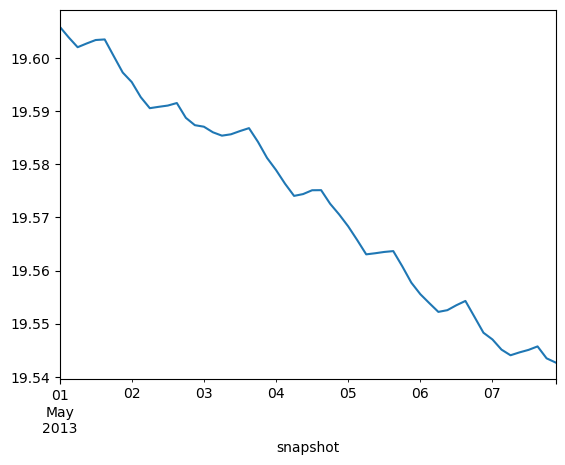

In [ ]:
(n.storage_units_t.state_of_charge.loc["2013-5-01":"2013-5-07", 'GH0 3 hydro'] / 1e6).plot()

In [ ]:
n.storage_units.p_nom * n.storage_units.max_hours

StorageUnit
GH0 3 hydro    4.020002e+07
GH0 8 hydro    1.592236e+07
dtype: float64